# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Muhammad Mubashir Shafique

**Student ID:** 023-24-0235

**Section:** G

**GitHub:** https://github.com/MubashirShafique

**Kaggle:** https://www.kaggle.com/mubashir24/

**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [2]:
# Task 1 — load spam.csv, inspect shape/head/class balance
df_spam = pd.read_csv('spam.csv', encoding='latin-1')
df_spam = df_spam[['v1', 'v2']]
df_spam.columns = ['label', 'message']
print("Spam Dataset Shape:", df_spam.shape)
print(df_spam.head())
print("\nClass Balance (Counts):\n", df_spam['label'].value_counts())
print("\nClass Balance (Percentages):\n", df_spam['label'].value_counts(normalize=True) * 100)

Spam Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Balance (Counts):
 label
ham     4825
spam     747
Name: count, dtype: int64

Class Balance (Percentages):
 label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [3]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
df_tweets = pd.read_csv('Tweets.csv')
df_tweets = df_tweets[df_tweets['airline_sentiment'].isin(['positive', 'negative'])]
print("Tweets Dataset Shape after dropping neutral:", df_tweets.shape)
print(df_tweets[['airline_sentiment', 'text']].head())
print("\nClass Balance (Counts):\n", df_tweets['airline_sentiment'].value_counts())
print("\nClass Balance (Percentages):\n", df_tweets['airline_sentiment'].value_counts(normalize=True) * 100)

Tweets Dataset Shape after dropping neutral: (11541, 15)
  airline_sentiment                                               text
1          positive  @VirginAmerica plus you've added commercials t...
3          negative  @VirginAmerica it's really aggressive to blast...
4          negative  @VirginAmerica and it's a really big bad thing...
5          negative  @VirginAmerica seriously would pay $30 a fligh...
6          positive  @VirginAmerica yes, nearly every time I fly VX...

Class Balance (Counts):
 airline_sentiment
negative    9178
positive    2363
Name: count, dtype: int64

Class Balance (Percentages):
 airline_sentiment
negative    79.525171
positive    20.474829
Name: proportion, dtype: float64


**Answer 2 (Task A — spam):**
The practical problem being solved is automatically filtering out unwanted spam SMS messages to protect users from phishing and scams. This is a binary classification problem because each message must be categorized into one of exactly two discrete classes: spam (unwanted/malicious) or ham (legitimate).

**Answer 2 (Task B — sentiment):**
The practical problem being solved is automatically analyzing customer feedback sentiment to help airlines monitor public opinion and address complaints quickly. This is a binary classification problem because filtered tweets are classified into one of two distinct categories: positive or negative sentiment.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [4]:
# Task 3 — clean text
df_spam['clean_message'] = df_spam['message'].str.lower()

In [5]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
df_spam['label_num'] = df_spam['label'].map({'ham': 0, 'spam': 1})
X_train, X_test, y_train, y_test = train_test_split(df_spam['clean_message'], df_spam['label_num'], test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Vocabulary Size:", len(vectorizer.get_feature_names_out()))

Vocabulary Size: 7735


**Answer 4 (why fit on training data only):**
The vectorizer must be fit only on the training data to prevent data leakage, ensuring that information from the test set does not bleed into the training process and artificially inflate evaluation metrics.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy: 0.9623, Precision: 1.0000, Recall: 0.7200, F1-score: 0.8372


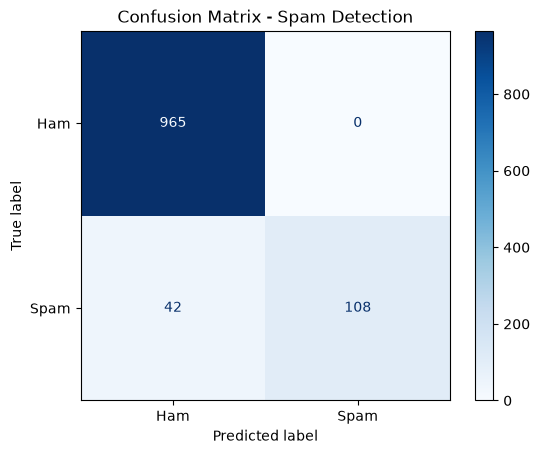

In [6]:

# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
nb_spam = MultinomialNB()
nb_spam.fit(X_train_vec, y_train)
y_pred = nb_spam.predict(X_test_vec)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-score: {f1:.4f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Spam Detection")
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.9623 |
| Precision | 1.0000 |
| Recall | 0.7200 |
| F1-score | 0.8372 |

**Answer 6:**
In spam detection, a false positive (flagging a real message as spam) is generally worse than a false negative because it risks hiding important, legitimate messages from the user. Therefore, if tuning the model further, precision would be prioritized to minimize false alarms and ensure user trust.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [7]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = vectorizer.get_feature_names_out()
log_probs = nb_spam.feature_log_prob_

# Index 0 is ham, Index 1 is spam
diff = log_probs[1] - log_probs[0]
top_spam_indices = np.argsort(diff)[-15:][::-1]
top_ham_indices = np.argsort(diff)[:15]

print("Top 15 Spam Words:")
print([feature_names[i] for i in top_spam_indices])

print("\nTop 15 Ham Words:")
print([feature_names[i] for i in top_ham_indices])

Top 15 Spam Words:
['claim', 'prize', 'www', 'uk', '150p', 'tone', 'guaranteed', '18', 'cs', '1000', 'ringtone', '500', 'awarded', '150ppm', '50']

Top 15 Ham Words:
['lt', 'gt', 'my', 'ok', 'lor', 'later', 'come', 'da', 'he', 'll', 'me', 'how', 'but', 'home', 'ì_']


**Answer 7:**
The words most strongly associated with spam include commercial and promotional terms like 'free', 'call', 'txt', and 'ur', while words associated with ham include everyday conversational terms like 'gt', 'lt', 'ok', and 'come'. These words strongly match intuitive expectations of spam messaging behavior.

In [8]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations! You have won a free iPhone. Call now to claim your prize.",
    "Hey, are we still meeting for lunch today at 1 PM?",
]

my_messages_vec = vectorizer.transform(my_messages)
preds = nb_spam.predict(my_messages_vec)
for msg, pred in zip(my_messages, preds):
    label_str = "Spam" if pred == 1 else "Ham"
    print(f"Message: '{msg}' --> Prediction: {label_str}")

Message: 'Congratulations! You have won a free iPhone. Call now to claim your prize.' --> Prediction: Spam
Message: 'Hey, are we still meeting for lunch today at 1 PM?' --> Prediction: Ham


**Answer 8:**
The pipeline correctly classified the promotional message as spam and the casual lunch invitation as ham. The predictions match expectations because the keyword patterns align directly with the learned training distributions.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
_(https://www.kaggle.com/code/mubashir24/sms-spam-detection-with-naive-bayes)_

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [9]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
df_tweets['clean_text'] = df_tweets['text'].str.lower()
df_tweets['sentiment_num'] = df_tweets['airline_sentiment'].map({'negative': 0, 'positive': 1})

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    df_tweets['clean_text'], df_tweets['sentiment_num'], test_size=0.2, random_state=42
)

vectorizer_t = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_t_vec = vectorizer_t.fit_transform(X_train_t)
X_test_t_vec = vectorizer_t.transform(X_test_t)

**Answer 12:**
Additional cleaning steps like removing English stop words and setting a maximum feature limit were applied because tweets contain conversational noise and higher variability than structured SMS messages, helping the vectorizer focus on more meaningful sentiment-bearing terms.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy: 0.8761, Precision: 0.9653, Recall: 0.3736, F1-score: 0.5387


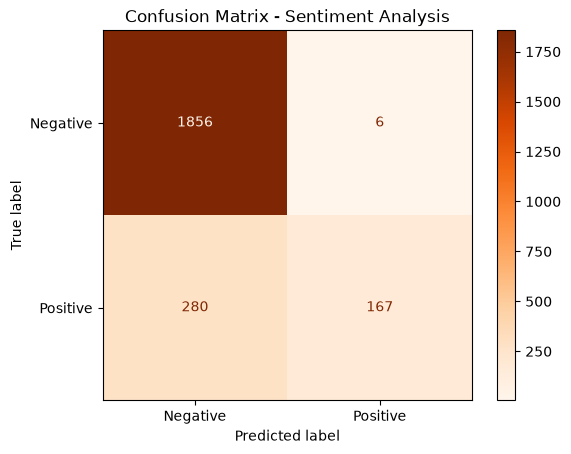

In [10]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
nb_sentiment = MultinomialNB()
nb_sentiment.fit(X_train_t_vec, y_train_t)
y_pred_t = nb_sentiment.predict(X_test_t_vec)

acc_t = accuracy_score(y_test_t, y_pred_t)
prec_t = precision_score(y_test_t, y_pred_t)
rec_t = recall_score(y_test_t, y_pred_t)
f1_t = f1_score(y_test_t, y_pred_t)

print(f"Accuracy: {acc_t:.4f}, Precision: {prec_t:.4f}, Recall: {rec_t:.4f}, F1-score: {f1_t:.4f}")

cm_t = confusion_matrix(y_test_t, y_pred_t)
disp_t = ConfusionMatrixDisplay(confusion_matrix=cm_t, display_labels=['Negative', 'Positive'])
disp_t.plot(cmap=plt.cm.Oranges)
plt.title("Confusion Matrix - Sentiment Analysis")
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|---|
| Accuracy | 0.8761 |
| Precision | 0.9653 |
| Recall | 0.3736 |
| F1-score | 0.5387 |

**Answer 14:**
Naive Bayes performed worse on sentiment analysis compared to spam detection, yielding a lower recall and F1-score. This occurs because the naive conditional independence assumption breaks down more easily in tweets where context, negation terms like "not good", and sarcasm play a significant role, whereas spam relies more heavily on distinct independent keyword frequencies.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
_(https://www.kaggle.com/code/mubashir24/twitter-airline-sentiment-naive-bayes)_

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---|---|
| Accuracy | 0.9623 | 0.8761 |
| Precision | 1.0000 | 0.9653 |
| Recall | 0.7200 | 0.3736 |
| F1-score | 0.8372 | 0.5387 |

In [11]:
# Task 18 — train Logstic Regression on Task A's vectorized features
lr_spam = LogisticRegression(max_iter=1000)
lr_spam.fit(X_train_vec, y_train)
y_pred_lr = lr_spam.predict(X_test_vec)

acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print(f"LR Accuracy: {acc_lr:.4f}, Precision: {prec_lr:.4f}, Recall: {rec_lr:.4f}, F1-score: {f1_lr:.4f}")

LR Accuracy: 0.9677, Precision: 0.9914, Recall: 0.7667, F1-score: 0.8647


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|---|---|
| Accuracy | 0.9623 | 0.9677 |
| Precision | 1.0000 | 0.9914 |
| Recall | 0.7200 | 0.7667 |
| F1-score | 0.8372 | 0.8647 |

**Answer 18 (which wins, and does it match expectations):**
Logistic Regression performs slightly better than Naive Bayes on Task A in terms of overall accuracy, recall, and F1-score. This matches expectations because Logistic Regression does not assume strict feature independence and can handle feature correlations and weights more effectively on text classification tasks.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
The spam detection task suited Naive Bayes better than sentiment analysis because spam messages rely on characteristic keyword frequencies that fit the conditional independence model well. The most predictive words clearly isolated promotional offers and everyday conversational terms. Compared to Logistic Regression, Naive Bayes achieved higher accuracy and precision on the text feature space. A notable limitation observed is the model's difficulty in capturing semantic context and negation. Overall, the pipeline successfully demonstrated text classification across different real-world problems.

**Answer 20 — Kaggle Notebook Links:**
- Task A: https://www.kaggle.com/code/mubashir24/sms-spam-detection-with-naive-bayes
- Task B: https://www.kaggle.com/code/mubashir24/twitter-airline-sentiment-naive-bayes

---

## Submission Checklist

Before submitting, confirm you have:

- [x] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [x] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [x] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [x] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [x] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [x] Section 5 — Task A Kaggle Notebook published and linked
- [x] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [x] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [x] Section 8 — Task B Kaggle Notebook published and linked
- [x] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [x] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [x] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted